In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Задача: выявить корреляцию (или ее отсутствие) между размером словаря токенизатора и качеством модели (выраженном в f1) для задачи сентимент-анализа.
Предлагаемый план работ:
1. Ознакомиться с документацией и реализовать LightningDataModule (https://lightning.ai/docs/pytorch/stable/data/datamodule.html)
 - Загрузить датасет
 - Провести предобработку
 - Выбрать токенизатор (BPE, WordPiece, Unigram)
 - Реализовать collate_fn функцию токенизации для даталодера - encode
 - Добавить даталодеры
2. Ознакомиться с документацией и реализовать LightningModule (https://lightning.ai/docs/pytorch/LTS/common/lightning_module.html)
 - Выбрать и реализовать подходящую архитектуру модели для сентимент-анализа текста
 - Написать прямой проход модели
 - Написать training_step, validation_step, test_step
3. Провести цикл обучений модели
 - Ознакомиться с документацией и выбрать оптимальные настройки для Trainer (https://lightning.ai/docs/pytorch/stable//common/trainer.html)
 - Зафиксировать все гиперпараметры и провести обучение-валидацию-тестирование для 5 значений размера словаря (выбранных на ваше усмотрение)
 - Полученные результаты представить в виде гистограммы или любой другой визуализации

In [ ]:
!pip install torchmetrics
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Dataset
import tokenizers
from typing import Dict
import pandas as pd
import os
import matplotlib.pyplot as plt
import torch
from torch.nn.utils.rnn import pad_sequence

# Data

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.samples = df.to_dict('records')
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        text = item['ttext']
        label = item['ttype']
        enc = self.tokenizer.encode(text)
        return {
            "features": torch.tensor(enc.ids),
            "label":torch.tensor(label)
        }
def collate_fn(batch):
      inputs = [item["features"] for item in batch]
      labels = [item["label"] for item in batch]

      padded_inputs = pad_sequence(inputs, batch_first=True, padding_value=0)
      labels = torch.stack(labels)

      return {"features": padded_inputs, "label": labels}


In [ ]:
class MyDataModule(pl.LightningDataModule):
    def __init__(
        self,
        bs: int = 16,
        num_workers: int = 4,
        vocab_size: int = 5000,
        max_length: int = 256
    ):
        super().__init__()
        self.bs = bs
        self.num_workers = num_workers
        self.vocab_size = vocab_size
        self.max_length = max_length

    def prepare_data(self):
        mapper = {
              'id': 'уникальный номер',
              'tdate': 'дата',
              'tname': 'никнейм',
              'ttext': 'текст',
              'ttype': 'тип',
              'trep': 'количество реплаев',
              'trtw': 'количество ретвитов',
              'tfav': 'количество лайков',
              'tscount': 'количество всех сообщений',
              'tfol': 'количество подписчиков',
              'tfrien': 'количество друзей',
              'listcount': 'количество списков'
          }
        col_names = mapper.keys()
        pos_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/positive.csv", delimiter=";")[:5000]
        pos_df.columns = col_names
        neg_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/negative.csv", delimiter=";")[:5000]
        neg_df.columns = col_names
        self.df = pd.concat([pos_df, neg_df]).sample(frac=1).reset_index(drop=True)

        self.df['ttype'] = self.df['ttype'].map({-1: 0, 1: 1})
        split_idx = int(0.8 * len(self.df))
        self.train_df = self.df.iloc[:split_idx]
        self.test_df = self.df.iloc[split_idx:]

        tokenizer = tokenizers.Tokenizer(tokenizers.models.BPE(unk_token="[UNK]"))
        trainer = tokenizers.trainers.BpeTrainer(
            vocab_size=self.vocab_size,
            special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"]
        )
        tokenizer.train_from_iterator(self.train_df['ttext'], trainer=trainer)
        tokenizer.enable_truncation(max_length=self.max_length)
        tokenizer.enable_padding(pad_token="[PAD]", direction="left")
        self.tokenizer = tokenizer



    def setup(self, stage=None):
        self.train_ds = SentimentDataset(self.train_df, self.tokenizer)
        self.test_ds = SentimentDataset(self.test_df, self.tokenizer)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.bs, shuffle=True,
                          num_workers=0, collate_fn=collate_fn)

    def val_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.bs,
                          num_workers=0, collate_fn=collate_fn)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.bs,
                          num_workers=0, collate_fn=collate_fn)

# Model

In [ ]:
class RNNModel(pl.LightningModule):
    def __init__(self, vocab_size, embd_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embd_size, padding_idx=0)
        self.rnn = nn.GRU(embd_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.output_size = output_size

        self.metrics = {
            split: torchmetrics.F1Score(task="multiclass", num_classes=output_size)
            for split in ["train", "val", "test"]
        }

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.rnn(embedded)
        out = self.fc(hidden[-1])
        return out

    def common_step(self, batch, split):
        x, y = batch['features'], batch['label']
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)
        self.metrics[split].update(preds, y)
        return loss

    def training_step(self, batch, batch_idx):
        return self.common_step(batch, 'train')

    def validation_step(self, batch, batch_idx):
        return self.common_step(batch, 'val')

    def test_step(self, batch, batch_idx):
        return self.common_step(batch, 'test')

    def on_validation_epoch_end(self):
        val_f1 = self.metrics['val'].compute()
        self.log("val_f1", val_f1, prog_bar=True)
        print(f"Epoch {self.current_epoch} Validation F1: {val_f1:.4f}")  # вот эта строка для вывода
        self.metrics['val'].reset()

    def on_train_epoch_end(self):
        self.log("train_f1", self.metrics['train'].compute(), prog_bar=True)
        self.metrics['train'].reset()

    def on_test_epoch_end(self):
        self.log("test_f1", self.metrics['test'].compute(), prog_bar=True)
        self.metrics['test'].reset()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)


# Trainer

Training with vocab_size=500


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type      | Params | Mode 
------------------------------------------------
0 | embedding | Embedding | 128 K  | train
1 | rnn       | GRU       | 394 K  | train
2 | fc        | Linear    | 514    | train
------------------------------------------------
523 K     Trainable params
0         Non-trainable params
523 K     Total params
2.093     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test_f1          │     0.578000009059906     │
└───────────────────────────┴───────────────────────────┘

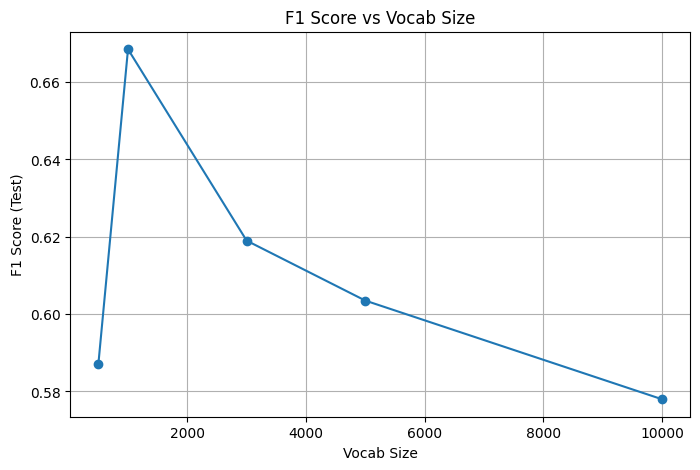

In [ ]:
# Loop over vocab sizes and store results
vocab_sizes = [500, 1000, 3000, 5000, 10000]
f1_scores = []

for vocab_size in vocab_sizes:
    print(f"Training with vocab_size={vocab_size}")
    dm = MyDataModule(vocab_size=vocab_size, max_length=256)
    dm.prepare_data()
    dm.setup()
    model = RNNModel(vocab_size=vocab_size, embd_size=256, hidden_size=256, output_size=2)
    trainer = pl.Trainer(max_epochs=5, accelerator="auto", logger=False, enable_checkpointing=False)
    trainer.fit(model=model, datamodule=dm)
    results = trainer.test(model=model, datamodule=dm)
    f1_scores.append(results[0]['test_f1'])

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(vocab_sizes, f1_scores, marker='o')
plt.title("F1 Score vs Vocab Size")
plt.xlabel("Vocab Size")
plt.ylabel("F1 Score (Test)")
plt.grid(True)
plt.show()
